In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.patches import Patch
from matplotlib.font_manager import FontProperties



# 1. DSSP Scores for all TFs

In [3]:
TF_dssp = pd.read_csv("../output/lambert_TF_AF_dssp.csv", index_col = 0)
TF_dssp

,pos,code,uniprotID
0,0,-,Q9NZC4
1,1,-,Q9NZC4
2,2,-,Q9NZC4
3,3,-,Q9NZC4
4,4,-,Q9NZC4
...,...,...,...
454,454,S,Q8TBJ5
455,455,S,Q8TBJ5
456,456,S,Q8TBJ5
457,457,-,Q8TBJ5


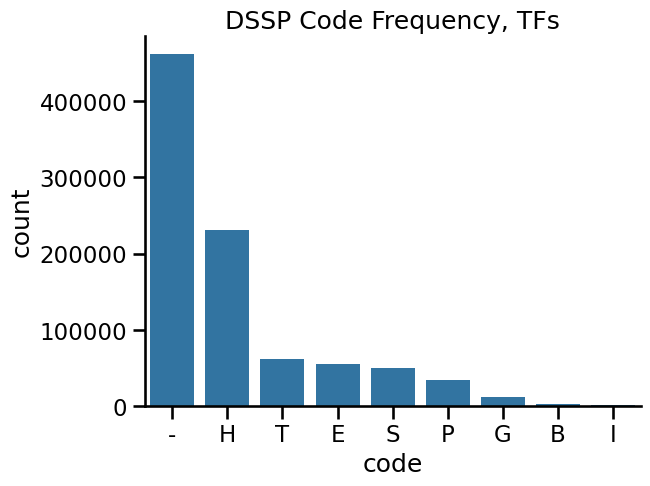

In [4]:
# G 3-turn helix (3_10 helix)
# H 4-turn helix (alpha-helix)
# I 5-turn helix (pi helix)

# E extended strand in parallel and/or anti-parallel β-sheet conformation. Min length 2 residues
# B residue in isolated β-bridge (single pair β-sheet hydrogen bond formation)

# P Polyproline

# T H-bonded turn
# S bend

# - coil 

sns.set_context('talk')
sns.barplot(TF_dssp["code"].value_counts())
sns.despine()
plt.title("DSSP Code Frequency, TFs")
plt.show()

# 2. Getting list of DBD positions

In [5]:
lambert_TFs = pd.read_csv("../output/lambert_TFs_10-21-24_with_DBD_coords.csv")
lambert_TFs["uniprotID"] = lambert_TFs["id"].str.split("|").str[1]
lambert_TFs["DBD_coords_merged"] = lambert_TFs["DBD_coords_merged"].str.split("],")
lambert_TFs

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[[221, 243, [249, 271, [277, 299, [305, 32...",A0A087WUV0
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[[114, 182, [262, 347]]]",A0AVK6
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[[260, 282, [288, 310, [316, 338, [344, 36...",A0PJY2
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[[1, 330]]]",A1A519
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[[364, 386, [392, 414, [420, 442, [448, 46...",A1YPR0
...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[[31, 83]]]",Q9Y6Q9
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[[165, 187, [193, 215, [221, 243, [249, 27...",Q9Y6R6
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[[583, 596, [1015, 1027, [1450, 1462]]]",Q9Y6X0
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[[78, 101, [110, 133, [271, 317, [442, 496...",Q9Y6X8


In [6]:
lambert_TFs_expanded = lambert_TFs.explode("DBD_coords_merged")[["uniprotID", "DBD_coords_merged"]]
lambert_TFs_expanded["Start"] = lambert_TFs_expanded["DBD_coords_merged"].str.extract(r'(\d+),')
lambert_TFs_expanded["End"] = lambert_TFs_expanded["DBD_coords_merged"].str.extract(r', (\d+)')
lambert_TFs_expanded = lambert_TFs_expanded.dropna()
lambert_TFs_expanded["Start"] = lambert_TFs_expanded["Start"].astype(int)
lambert_TFs_expanded["End"] = lambert_TFs_expanded["End"].astype(int)
lambert_TFs_expanded = lambert_TFs_expanded.drop(columns = "DBD_coords_merged")
lambert_TFs_expanded["intervals"] = [np.arange(start, end) for start, end in zip(lambert_TFs_expanded["Start"], lambert_TFs_expanded["End"])]
dbd_positions = lambert_TFs_expanded.explode("intervals")
dbd_positions = dbd_positions[["uniprotID", "intervals"]]
dbd_positions = dbd_positions.rename(columns = {"intervals" : "pos"})
dbd_positions = dbd_positions.reset_index(drop = True)
dbd_positions["DBD"] = True
dbd_positions

,uniprotID,pos,DBD
0,A0A087WUV0,221,True
1,A0A087WUV0,222,True
2,A0A087WUV0,223,True
3,A0A087WUV0,224,True
4,A0A087WUV0,225,True
...,...,...,...
270312,Q9Y6Y1,177,True
270313,Q9Y6Y1,178,True
270314,Q9Y6Y1,179,True
270315,Q9Y6Y1,180,True


# 3. Comparing DBD vs non DBD DSSP scores as a control

In [7]:
TF_dssp_with_dom = pd.merge(TF_dssp, dbd_positions, how = 'left')
TF_dssp_with_dom["DBD"] = TF_dssp_with_dom["DBD"].fillna(False)
display(TF_dssp_with_dom)
TF_dssp_with_dom["DBD"].value_counts()

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_26625/334060667.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  TF_dssp_with_dom["DBD"] = TF_dssp_with_dom["DBD"].fillna(False)


,pos,code,uniprotID,DBD
0,0,-,Q9NZC4,False
1,1,-,Q9NZC4,False
2,2,-,Q9NZC4,False
3,3,-,Q9NZC4,False
4,4,-,Q9NZC4,False
...,...,...,...,...
907792,454,S,Q8TBJ5,False
907793,455,S,Q8TBJ5,False
907794,456,S,Q8TBJ5,False
907795,457,-,Q8TBJ5,False


DBD
False    643672
True     264125
Name: count, dtype: int64

In [8]:
dbd_rows = TF_dssp_with_dom[TF_dssp_with_dom["DBD"]]
display(dbd_rows)
non_dbd_rows = TF_dssp_with_dom[~TF_dssp_with_dom["DBD"]]
display(non_dbd_rows)

,pos,code,uniprotID,DBD
208,208,H,Q9NZC4,True
209,209,H,Q9NZC4,True
210,210,H,Q9NZC4,True
211,211,H,Q9NZC4,True
212,212,H,Q9NZC4,True
...,...,...,...,...
907773,435,H,Q8TBJ5,True
907774,436,H,Q8TBJ5,True
907775,437,H,Q8TBJ5,True
907776,438,H,Q8TBJ5,True


,pos,code,uniprotID,DBD
0,0,-,Q9NZC4,False
1,1,-,Q9NZC4,False
2,2,-,Q9NZC4,False
3,3,-,Q9NZC4,False
4,4,-,Q9NZC4,False
...,...,...,...,...
907792,454,S,Q8TBJ5,False
907793,455,S,Q8TBJ5,False
907794,456,S,Q8TBJ5,False
907795,457,-,Q8TBJ5,False


In [9]:
DBD_code_counts = TF_dssp_with_dom.groupby(["DBD", "code"])[["DBD", "code"]].size().reset_index()
DBD_code_counts.columns = ['DBD', 'code', 'count']
DBD_code_counts

,DBD,code,count
0,False,-,404429
1,False,B,1449
2,False,E,24151
3,False,G,9223
4,False,H,116278
5,False,I,524
6,False,P,28983
7,False,S,27254
8,False,T,31381
9,True,-,56967


In [10]:
DBD_code_props = pd.merge(DBD_code_counts, DBD_code_counts.groupby("DBD").sum().reset_index().drop(columns = "code"), on = "DBD")
DBD_code_props["prop"] = DBD_code_props["count_x"] / DBD_code_props["count_y"]
DBD_code_props = DBD_code_props.sort_values(by = ["DBD", "prop"], ascending = [False, False])
DBD_code_props

,DBD,code,count_x,count_y,prop
13,True,H,113969,264125,0.431496
9,True,-,56967,264125,0.215682
11,True,E,30863,264125,0.116850
17,True,T,30349,264125,0.114904
16,True,S,22628,264125,0.085672
15,True,P,4748,264125,0.017976
12,True,G,2871,264125,0.010870
10,True,B,889,264125,0.003366
14,True,I,841,264125,0.003184
0,False,-,404429,643672,0.628315


In [11]:
sns.color_palette("Paired")

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [12]:
# Define custom colors
DBD_custom_palette = {
    True: sns.color_palette("Paired")[-3],   # Dark purple
    False: sns.color_palette("Paired")[-4]
}

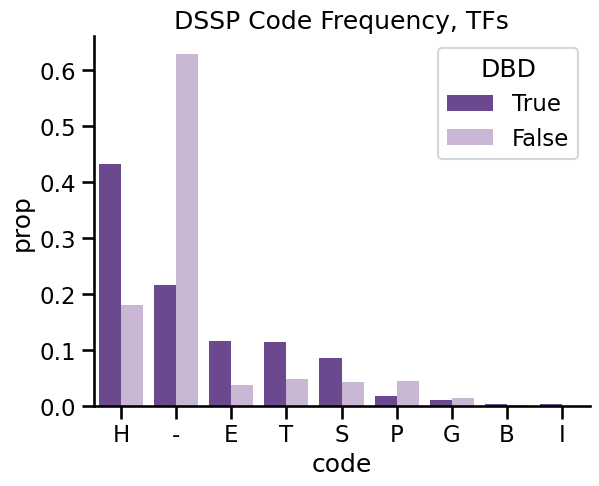

In [13]:
sns.barplot(x=DBD_code_props["code"], y=DBD_code_props["prop"], hue = DBD_code_props["DBD"], hue_order = [True, False], palette = DBD_custom_palette)
sns.despine()
plt.title("DSSP Code Frequency, TFs");
# Makes sense - 

# 4. Comparing AD vs non AD position DBD codes.

In [18]:
known_ADs = pd.read_csv("../output/known_ADs_considering_isoforms_and_canonical_with_alerasool.csv")

In [19]:
known_ADs["intervals"] = [np.arange(start, end) for start, end in zip(known_ADs["Start"], known_ADs["End"])]
ad_positions = known_ADs.explode("intervals")
ad_positions = ad_positions[["uniprotID", "intervals"]]
ad_positions = ad_positions.rename(columns = {"intervals" : "pos"})
ad_positions = ad_positions.reset_index(drop = True)
ad_positions["AD"] = True
ad_positions

,uniprotID,pos,AD
0,Q6UWZ7,121,True
1,Q6UWZ7,122,True
2,Q6UWZ7,123,True
3,Q6UWZ7,124,True
4,Q6UWZ7,125,True
...,...,...,...
90432,B2RXH4,535,True
90433,B2RXH4,536,True
90434,B2RXH4,537,True
90435,B2RXH4,538,True


In [20]:
TF_dssp_with_dom = pd.merge(TF_dssp_with_dom, ad_positions, how = 'left')
TF_dssp_with_dom["AD"] = TF_dssp_with_dom["AD"].fillna(False)
display(TF_dssp_with_dom)
TF_dssp_with_dom["AD"].value_counts()

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_26625/653806857.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  TF_dssp_with_dom["AD"] = TF_dssp_with_dom["AD"].fillna(False)


,pos,code,uniprotID,DBD,AD
0,0,-,Q9NZC4,False,False
1,1,-,Q9NZC4,False,False
2,2,-,Q9NZC4,False,False
3,3,-,Q9NZC4,False,False
4,4,-,Q9NZC4,False,False
...,...,...,...,...,...
907792,454,S,Q8TBJ5,False,False
907793,455,S,Q8TBJ5,False,False
907794,456,S,Q8TBJ5,False,False
907795,457,-,Q8TBJ5,False,False


AD
False    834117
True      73680
Name: count, dtype: int64

In [21]:
ad_rows = TF_dssp_with_dom[TF_dssp_with_dom["AD"]]
display(ad_rows)
non_ad_rows = TF_dssp_with_dom[~TF_dssp_with_dom["AD"]]
display(non_ad_rows)

,pos,code,uniprotID,DBD,AD
301,1,-,Q9Y2D1,False,True
302,2,-,Q9Y2D1,False,True
303,3,-,Q9Y2D1,False,True
304,4,-,Q9Y2D1,False,True
305,5,-,Q9Y2D1,False,True
...,...,...,...,...,...
905945,306,S,P10914,False,True
905946,307,T,P10914,False,True
905947,308,T,P10914,False,True
905948,309,-,P10914,False,True


,pos,code,uniprotID,DBD,AD
0,0,-,Q9NZC4,False,False
1,1,-,Q9NZC4,False,False
2,2,-,Q9NZC4,False,False
3,3,-,Q9NZC4,False,False
4,4,-,Q9NZC4,False,False
...,...,...,...,...,...
907792,454,S,Q8TBJ5,False,False
907793,455,S,Q8TBJ5,False,False
907794,456,S,Q8TBJ5,False,False
907795,457,-,Q8TBJ5,False,False


In [22]:
AD_code_counts = TF_dssp_with_dom.groupby(["AD", "code"])[["AD", "code"]].size().reset_index()
AD_code_counts.columns = ['AD', 'code', 'count']
AD_code_counts

,AD,code,count
0,False,-,410378
1,False,B,2247
2,False,E,53207
3,False,G,11000
4,False,H,220302
5,False,I,1324
6,False,P,29630
7,False,S,47307
8,False,T,58722
9,True,-,51018


In [23]:
AD_code_props = pd.merge(AD_code_counts, AD_code_counts.groupby("AD").sum().reset_index().drop(columns = "code"), on = "AD")
AD_code_props["prop"] = AD_code_props["count_x"] / AD_code_props["count_y"]
AD_code_props = AD_code_props.sort_values(by = ["AD", "prop"], ascending = False)
AD_code_props

,AD,code,count_x,count_y,prop
9,True,-,51018,73680,0.692427
13,True,H,9945,73680,0.134976
15,True,P,4101,73680,0.055660
17,True,T,3008,73680,0.040825
16,True,S,2575,73680,0.034948
11,True,E,1807,73680,0.024525
12,True,G,1094,73680,0.014848
10,True,B,91,73680,0.001235
14,True,I,41,73680,0.000556
0,False,-,410378,834117,0.491991


In [24]:
# Define custom colors
AD_custom_palette = {
    True: sns.color_palette("Paired")[-5],   # Dark purple
    False: sns.color_palette("Paired")[-6]
}

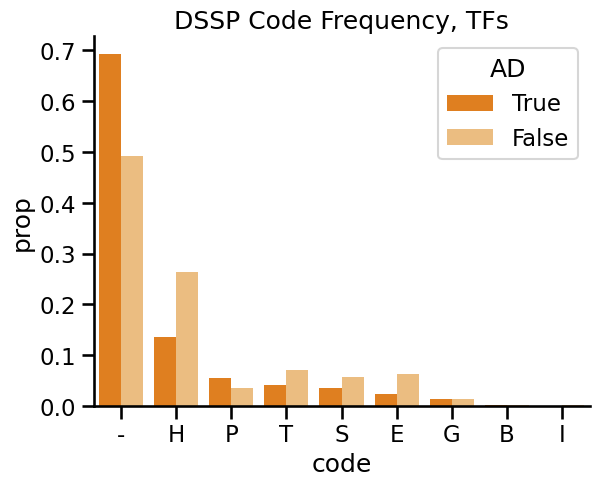

In [25]:
sns.barplot(x=AD_code_props["code"], y=AD_code_props["prop"], hue = AD_code_props["AD"], hue_order = [True, False], palette = AD_custom_palette)
sns.despine()
plt.title("DSSP Code Frequency, TFs");
# Makes sense - 

# 5. Activator TFs vs non activator TFs, outside of the DBD?

In [26]:
TF_dssp_with_dom

,pos,code,uniprotID,DBD,AD
0,0,-,Q9NZC4,False,False
1,1,-,Q9NZC4,False,False
2,2,-,Q9NZC4,False,False
3,3,-,Q9NZC4,False,False
4,4,-,Q9NZC4,False,False
...,...,...,...,...,...
907792,454,S,Q8TBJ5,False,False
907793,455,S,Q8TBJ5,False,False
907794,456,S,Q8TBJ5,False,False
907795,457,-,Q8TBJ5,False,False


In [47]:
# activator_TFs = pd.read_csv("../soto_analysis/outputs/all_TFs_table_proteins_activators.txt", sep = "\t")
# activator_TFs

In [48]:
TF_dssp_with_dom["activator TF"] = TF_dssp_with_dom["uniprotID"].isin(known_ADs["uniprotID"])
TF_dssp_with_dom

,pos,code,uniprotID,DBD,AD,activator TF
0,0,-,Q9NZC4,False,False,False
1,1,-,Q9NZC4,False,False,False
2,2,-,Q9NZC4,False,False,False
3,3,-,Q9NZC4,False,False,False
4,4,-,Q9NZC4,False,False,False
...,...,...,...,...,...,...
907792,454,S,Q8TBJ5,False,False,False
907793,455,S,Q8TBJ5,False,False,False
907794,456,S,Q8TBJ5,False,False,False
907795,457,-,Q8TBJ5,False,False,False


In [49]:
non_AD_positions = TF_dssp_with_dom[~TF_dssp_with_dom["AD"]]
non_AD_positions

,pos,code,uniprotID,DBD,AD,activator TF
0,0,-,Q9NZC4,False,False,False
1,1,-,Q9NZC4,False,False,False
2,2,-,Q9NZC4,False,False,False
3,3,-,Q9NZC4,False,False,False
4,4,-,Q9NZC4,False,False,False
...,...,...,...,...,...,...
907792,454,S,Q8TBJ5,False,False,False
907793,455,S,Q8TBJ5,False,False,False
907794,456,S,Q8TBJ5,False,False,False
907795,457,-,Q8TBJ5,False,False,False


In [50]:
non_AD_activator_TF_code_counts = non_AD_positions.groupby(["activator TF", "code"])[["activator TF", "code"]].size().reset_index()
non_AD_activator_TF_code_counts.columns = ["activator TF", 'code', 'count']
non_AD_activator_TF_code_props = pd.merge(non_AD_activator_TF_code_counts, non_AD_activator_TF_code_counts.groupby("activator TF").sum().reset_index().drop(columns = "code"), on = "activator TF")
non_AD_activator_TF_code_props["prop"] = non_AD_activator_TF_code_props["count_x"] / non_AD_activator_TF_code_props["count_y"]
non_AD_activator_TF_code_props = non_AD_activator_TF_code_props.sort_values(by = ["activator TF", "prop"], ascending = False)
non_AD_activator_TF_code_props

,activator TF,code,count_x,count_y,prop
9,True,-,89429,174852,0.511455
13,True,H,42045,174852,0.240461
11,True,E,11303,174852,0.064643
17,True,T,11264,174852,0.064420
16,True,S,8911,174852,0.050963
15,True,P,7619,174852,0.043574
12,True,G,3140,174852,0.017958
10,True,B,673,174852,0.003849
14,True,I,468,174852,0.002677
0,False,-,320949,659265,0.486829


In [51]:
sns.color_palette("Paired")

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [52]:
outside_AD_custom_palette = {True: sns.color_palette("Paired")[1],
                             False: sns.color_palette("Paired")[0]}

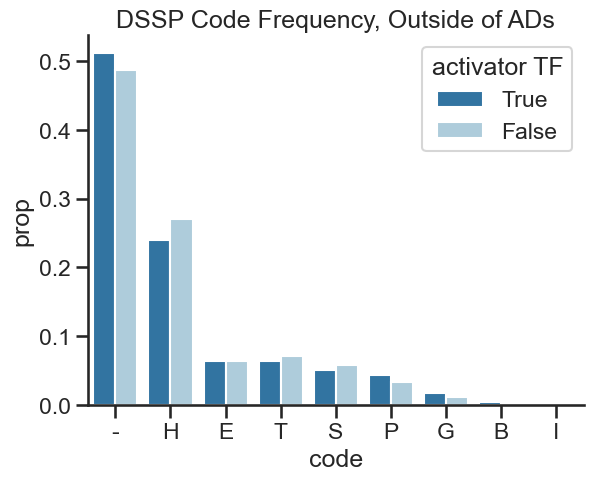

In [53]:
sns.barplot(x=non_AD_activator_TF_code_props["code"], y=non_AD_activator_TF_code_props["prop"], hue=non_AD_activator_TF_code_props["activator TF"], palette=outside_AD_custom_palette, hue_order=[True, False])
sns.despine()
plt.title("DSSP Code Frequency, Outside of ADs");
# Makes sense - 

Text(0.55, 1.05, 'Lambert TFs Secondary Structure')

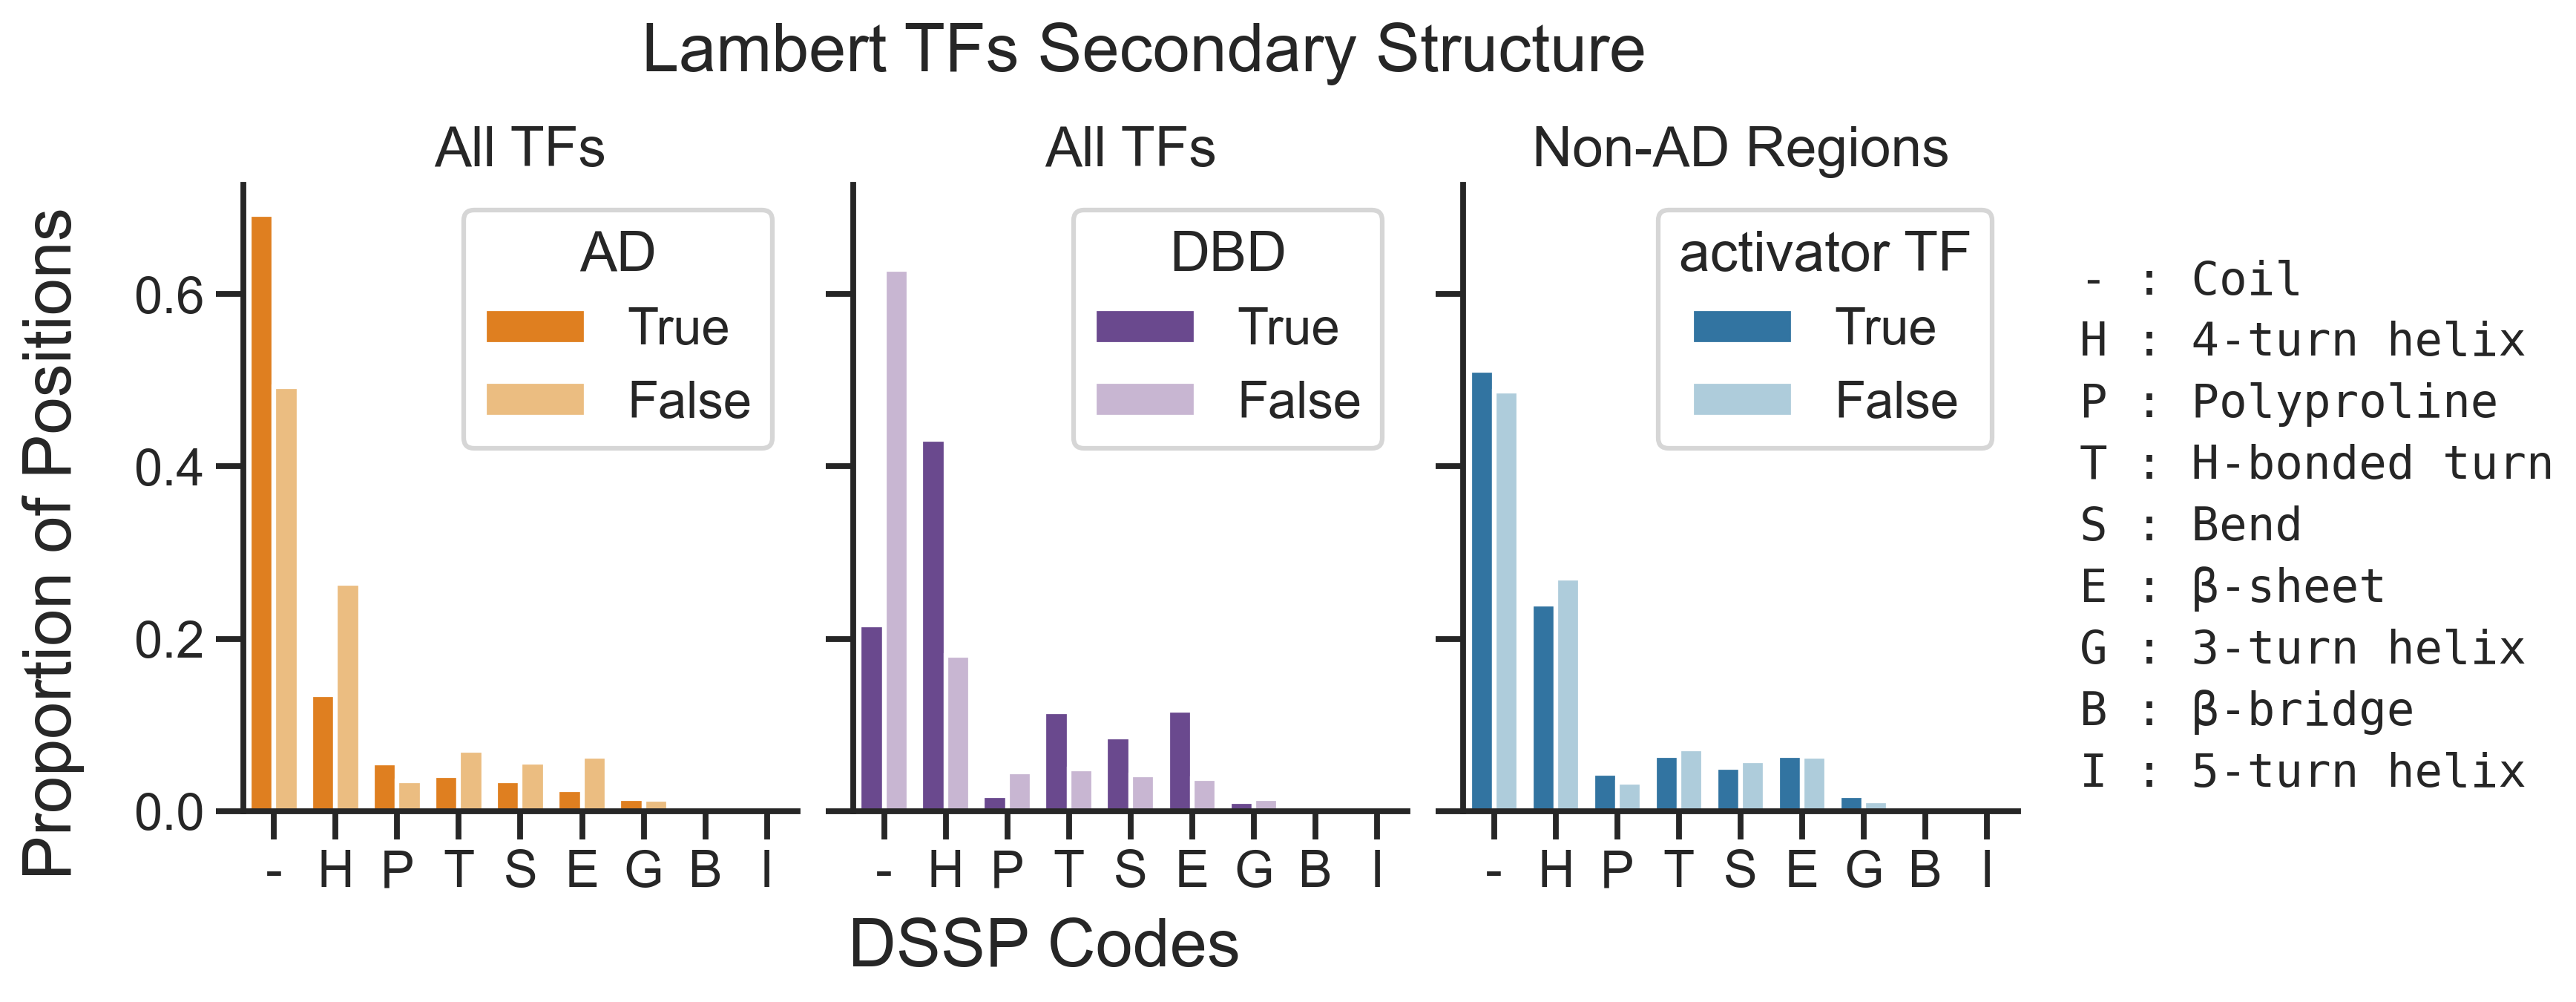

In [54]:
sns.set_context('talk')
sns.set_style('ticks')

fig, axs = plt.subplots(1, 3, sharey = True, figsize = (9, 4), sharex = True, dpi = 300)

axs[0].set_title("All TFs")
sns.barplot(x=AD_code_props["code"], y=AD_code_props["prop"], hue = AD_code_props["AD"], hue_order = [True, False], palette = AD_custom_palette, ax = axs[0])


axs[1].set_title("All TFs")
sns.barplot(x=DBD_code_props["code"], y=DBD_code_props["prop"], hue = DBD_code_props["DBD"], hue_order = [True, False], palette = DBD_custom_palette, ax = axs[1])


sns.barplot(x=non_AD_activator_TF_code_props["code"], y=non_AD_activator_TF_code_props["prop"], hue=non_AD_activator_TF_code_props["activator TF"], palette=outside_AD_custom_palette, hue_order=[True, False], ax = axs[2])
axs[2].set_title("Non-AD Regions")
sns.despine()
plt.tight_layout(pad = 0.5)

for ax in axs:
    ax.set_xlabel("")

fig.supxlabel("DSSP Codes")
fig.supylabel("Proportion of Positions", x = -0.01)

axs[0].set_ylabel("")

# DSSP code legend labels
dssp_legend_labels = {
    "-": "- : Coil",
    "H": "H : 4-turn helix",
    "P": "P : Polyproline",
    "T": "T : H-bonded turn",
    "S": "S : Bend",
    "E": "E : β-sheet",
    "G": "G : 3-turn helix",
    "B": "B : β-bridge",
    "I": "I : 5-turn helix"
}

for i in np.arange(len(dssp_legend_labels)):
    axs[2].text(x = 9.5, y = 0.6 - i / 14, s = list(dssp_legend_labels.values())[i], font = 'monospace', fontsize = 'small')


# dssp_handles = [Patch(facecolor="none", label=desc) for code, desc in dssp_legend_labels.items()]
# legend1 = plt.legend(title="DBD Present", loc="upper right", prop = FontProperties(family="monospace"))  # default hue legend
# plt.gca().add_artist(legend1)  # keep it when adding a second legend

# plt.legend(handles=dssp_handles, loc="center left", bbox_to_anchor=(1, 0.5))

plt.suptitle("Lambert TFs Secondary Structure", fontsize='large', va = 'center', ha = 'center', x = 0.55, y = 1.05)


In [55]:
# G 3-turn helix (3_10 helix)
# H 4-turn helix (alpha-helix)
# I 5-turn helix (pi helix)

# E extended strand in parallel and/or anti-parallel β-sheet conformation. Min length 2 residues
# B residue in isolated β-bridge (single pair β-sheet hydrogen bond formation)

# P Polyproline

# T H-bonded turn
# S bend

# - coil 

# Heatmap visual

In [56]:
TF_dssp_with_dom

,pos,code,uniprotID,DBD,AD,activator TF
0,0,-,Q9NZC4,False,False,False
1,1,-,Q9NZC4,False,False,False
2,2,-,Q9NZC4,False,False,False
3,3,-,Q9NZC4,False,False,False
4,4,-,Q9NZC4,False,False,False
...,...,...,...,...,...,...
907792,454,S,Q8TBJ5,False,False,False
907793,455,S,Q8TBJ5,False,False,False
907794,456,S,Q8TBJ5,False,False,False
907795,457,-,Q8TBJ5,False,False,False


In [57]:
summary = pd.DataFrame(TF_dssp_with_dom.groupby(["activator TF", "AD", "DBD"])["code"].value_counts()).reset_index()
summary

,activator TF,AD,DBD,code,count
0,False,False,False,-,277339
1,False,False,False,H,85805
2,False,False,False,T,22265
3,False,False,False,S,19838
4,False,False,False,P,19094
5,False,False,False,E,17447
6,False,False,False,G,6062
7,False,False,False,B,992
8,False,False,False,I,308
9,False,False,True,H,92452


In [60]:
pivot_summary_counts = pd.pivot(summary, index = ["activator TF", "AD", "DBD"], columns = "code", values = "count")
pivot_summary_counts

code                           -    B      E     G      H    I      P      S  \
activator TF AD    DBD                                                         
False        False False  277339  992  17447  6062  85805  308  19094  19838   
                   True    43610  582  24457  1798  92452  548   2917  18558   
True         False False   77678  376   5124  2123  21383  185   5924   5052   
                   True    11751  297   6179  1017  20662  283   1695   3859   
             True  False   49412   81   1580  1038   9090   31   3965   2364   
                   True     1606   10    227    56    855   10    136    211   

code                          T  
activator TF AD    DBD           
False        False False  22265  
                   True   25193  
True         False False   6306  
                   True    4958  
             True  False   2810  
                   True     198

In [80]:
pivot_summary_counts["domain_counts"] = pivot_summary_counts.index.get_level_values("AD").astype(int) + pivot_summary_counts.index.get_level_values("DBD").astype(int)
pivot_summary_counts

code                           -    B      E     G      H    I      P      S  \
activator TF AD    DBD                                                         
False        False False  277339  992  17447  6062  85805  308  19094  19838   
                   True    43610  582  24457  1798  92452  548   2917  18558   
True         False False   77678  376   5124  2123  21383  185   5924   5052   
                   True    11751  297   6179  1017  20662  283   1695   3859   
             True  False   49412   81   1580  1038   9090   31   3965   2364   
                   True     1606   10    227    56    855   10    136    211   

code                          T  domain_counts  
activator TF AD    DBD                          
False        False False  22265              0  
                   True   25193              1  
True         False False   6306              0  
                   True    4958              1  
             True  False   2810              1  
                   True     198              2

In [85]:
pivot_summary_counts = pivot_summary_counts[pivot_summary_counts["domain_counts"] < 2]
pivot_summary_counts = pivot_summary_counts.drop(columns = ["domain_counts"])
pivot_summary_counts

KeyError: 'domain_counts'

In [ ]:
normalized_counts = pivot_summary_counts.div(pivot_summary_counts.sum(axis=1), axis=0)
normalized_counts

code                             -         B         E         G         H  \
activator TF AD    DBD                                                       
False        False False  0.617475  0.002209  0.038844  0.013497  0.191039   
                   True   0.207553  0.002770  0.116398  0.008557  0.440007   
True         False False  0.625674  0.003029  0.041272  0.017100  0.172234   
                   True   0.231771  0.005858  0.121871  0.020059  0.407526   
             True  False  0.702164  0.001151  0.022452  0.014750  0.129173   

code                             I         P         S         T  
activator TF AD    DBD                                            
False        False False  0.000686  0.042511  0.044168  0.049571  
                   True   0.002608  0.013883  0.088323  0.119901  
True         False False  0.001490  0.047716  0.040692  0.050793  
                   True   0.005582  0.033431  0.076113  0.097789  
             True  False  0.000441  0.056344  0.033593  0.039931

Text(92.24999999999999, 0.5, '')

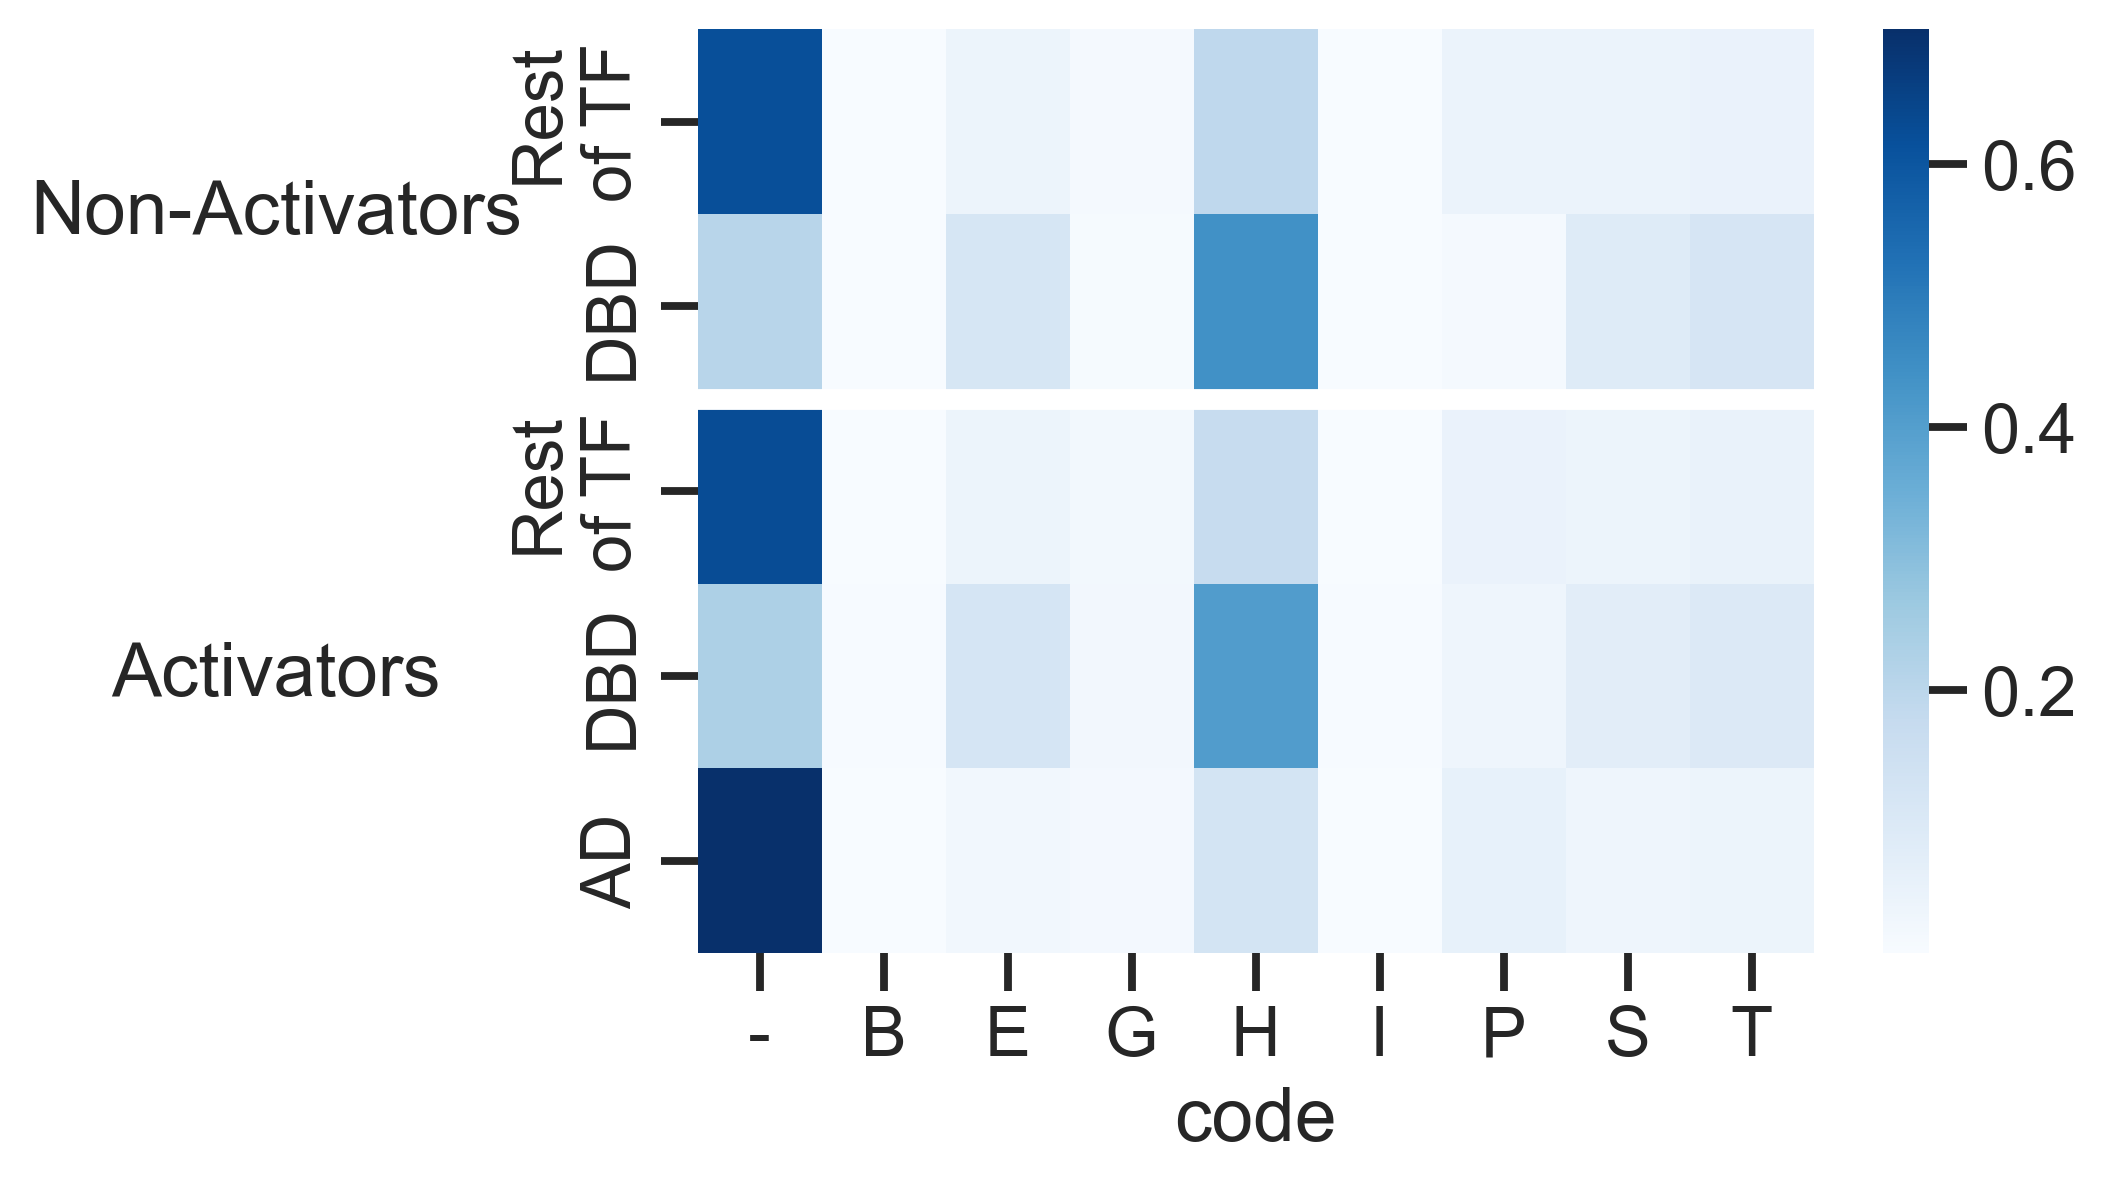

In [118]:
fig, ax = plt.subplots(figsize = (6, 4), dpi = 300)
sns.heatmap(normalized_counts, cmap = "Blues", ax=ax)
ax.axhline(2, color = 'white', linewidth = 5)
custom_labels = ["Rest\nof TF", "DBD", "Rest\nof TF", "DBD", "AD"]
plt.yticks(ticks= np.arange(len(custom_labels)) + 0.5, labels=custom_labels, rotation = 90)
plt.text(-3.4, 1, "Non-Activators", rotation = 0, ha = 'center', va = 'center')
plt.text(-3.4, 3.5, "Activators", rotation = 0, ha = 'center', va = 'center')
plt.ylabel("")